<a href="https://colab.research.google.com/github/victorolivoiaoa-ux/everpeak-analysis/blob/main/everpeak_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# EverPeak Retail: Pipeline de Limpieza, EDA y Segmentación
Este cuaderno integra el preprocesamiento de datos, análisis exploratorio (EDA), detección de valores atípicos (outliers) y segmentación avanzada del caso **EverPeak–SilverBasket**.

In [1]:
# 1. Configuración de librerías y carga del dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# URL directa al dataset público de EverPeak
url = "https://practicum-content.s3.us-west-1.amazonaws.com/datasets/everpeak_retail.csv"
df = pd.read_csv(url)

print("Dimensiones iniciales:", df.shape)
df.head()

Dimensiones iniciales: (5008, 11)


,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66.0
1,2,2024-10-10,1736,Grocery,66,0,660,debit_card,Los Angeles,CA,24.0
2,3,2024-08-27,2543,Sports,267,0,5073,credit_card,Chicago,IL,23.0
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70.0
4,5,2024-06-07,1583,Fashion,729,16,11754,credit_card,Houston,TX,75.0


## 1. Diagnóstico Inicial de Calidad de Datos
Revisión de valores ausentes, formatos inconsistentes en fechas y cardinalidad de variables categóricas.

In [2]:
# Diagnóstico de nulos
print("--- Valores ausentes iniciales ---")
print(df[["payment_method", "city", "state", "customer_age", "price"]].isna().sum())

# Análisis de fechas y detección de años atípicos
order_dates_dt = pd.to_datetime(df["order_date"], errors="coerce")
invalid_2026 = (order_dates_dt.dt.year == 2026).sum()
print(f"\nRegistros con año atípico (2026): {invalid_2026}")

# Cardinalidad
print("\n--- Valores únicos por columna ---")
for col in ["customer_id", "payment_method", "city", "state"]:
    print(f"{col}: {df[col].nunique()} únicos")

--- Valores ausentes iniciales ---
payment_method      0
city              100
state             100
customer_age      150
price               0
dtype: int64

Registros con año atípico (2026): 15

--- Valores únicos por columna ---
customer_id: 1829 únicos
payment_method: 4 únicos
city: 10 únicos
state: 9 únicos


## 2. Pipeline de Limpieza y Estandarización
Construcción de funciones modulares para:
1. Estandarizar cadenas de texto (`strip`).
2. Tratar valores centinela (`-999, 999, 0, -1`).
3. Convertir tipos numéricos y rellenar nulos mediante imputación estadística.

In [3]:
def step_strip_text(df_in):
    """Elimina espacios en blanco en columnas de texto."""
    text_cols = ['product_category', 'city', 'state']
    for col in text_cols:
        if col in df_in.columns:
            df_in[col] = df_in[col].astype(str).str.strip()
    return df_in

def reemplazar_sentinels(df_in, sentinels, numeric_cols):
    """Reemplaza valores centinela por NaN."""
    for col in numeric_cols:
        df_in[col] = df_in[col].replace(sentinels, np.nan)
    return df_in

def convertir_y_rellenar_ausentes(df_in, num_cols):
    """Fuerza tipo numérico e imputa valores ausentes con la media."""
    for col in num_cols:
        df_in[col] = pd.to_numeric(df_in[col], errors="coerce")
        df_in[col] = df_in[col].fillna(df_in[col].mean())
    return df_in

def pipeline_limpieza(df_raw):
    """Pipeline integral de preprocesamiento."""
    df_clean = df_raw.copy()

    # 1. Limpieza de texto
    df_clean = step_strip_text(df_clean)

    # 2. Tratamiento de centinelas en columnas numéricas clave
    sentinels = [-999, 999, 0, -1]
    num_cols = ["customer_age", "price", "quantity", "order_value", "customer_id"]
    df_clean = reemplazar_sentinels(df_clean, sentinels, ["customer_age", "price"])

    # 3. Conversión de tipos y relleno de nulos
    df_clean = convertir_y_rellenar_ausentes(df_clean, num_cols)

    return df_clean

# Ejecutar pipeline
df_clean = pipeline_limpieza(df)
print("Valores ausentes tras el pipeline de limpieza:")
print(df_clean[["customer_age", "price", "order_value", "quantity"]].isna().sum())

Valores ausentes tras el pipeline de limpieza:
customer_age    0
price           0
order_value     0
quantity        0
dtype: int64


## 3. Análisis Exploratorio de Datos (EDA) y Distribuciones
Comparativas estadísticas por categorías y ciudades clave (New York vs Los Angeles / Chicago).

In [4]:
# Estadísticas descriptivas comparativas por ciudad
columnas_numericas = ['order_value', 'customer_age', 'price', 'quantity']

df_ny = df_clean[df_clean['city'] == 'New York']
df_la = df_clean[df_clean['city'] == 'Los Angeles']

print("--- Resumen Numérico: New York ---")
print(df_ny[columnas_numericas].describe())

print("\n--- Resumen Numérico: Los Angeles ---")
print(df_la[columnas_numericas].describe())

--- Resumen Numérico: New York ---
         order_value  customer_age         price     quantity
count     497.000000    497.000000    497.000000   497.000000
mean    10545.410463     49.853490    741.454728    25.384306
std     13914.329615     17.507334   1105.570500    76.226789
min        58.000000     18.000000     12.000000     0.000000
25%      2862.000000     35.000000    203.000000     0.000000
50%     10682.000000     49.122491    457.000000     0.000000
75%     13327.000000     64.000000    787.000000    23.000000
max    224884.000000     80.000000  11836.000000  1258.000000

--- Resumen Numérico: Los Angeles ---
         order_value  customer_age         price     quantity
count     511.000000    511.000000    511.000000   511.000000
mean    10456.168297     49.798596    750.332858    24.919765
std     15964.141858     17.694153   1174.680751    76.782500
min        44.000000     18.000000     13.000000     0.000000
25%      3164.000000     35.000000    204.000000     0.000

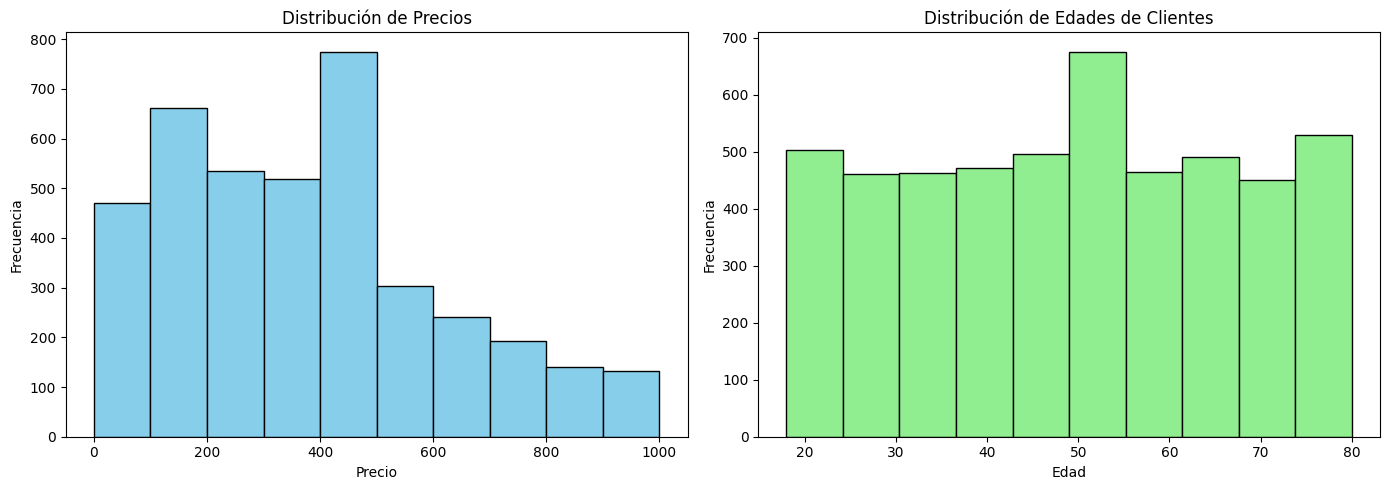

In [5]:
# Visualización de distribuciones: Precios y Edades
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de Precios
axes[0].hist(df_clean['price'], bins=10, range=(0, 1000), color='skyblue', edgecolor='black')
axes[0].set_title("Distribución de Precios")
axes[0].set_xlabel("Precio")
axes[0].set_ylabel("Frecuencia")

# Histograma de Edades
axes[1].hist(df_clean['customer_age'], bins=10, color='lightgreen', edgecolor='black')
axes[1].set_title("Distribución de Edades de Clientes")
axes[1].set_xlabel("Edad")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## 4. Detección y Análisis de Outliers
Evaluación de anomalías en gasto (`order_value`), volumen (`quantity`) y precio (`price`) utilizando **Rango Intercuartílico (IQR)** y **Z-Score**.

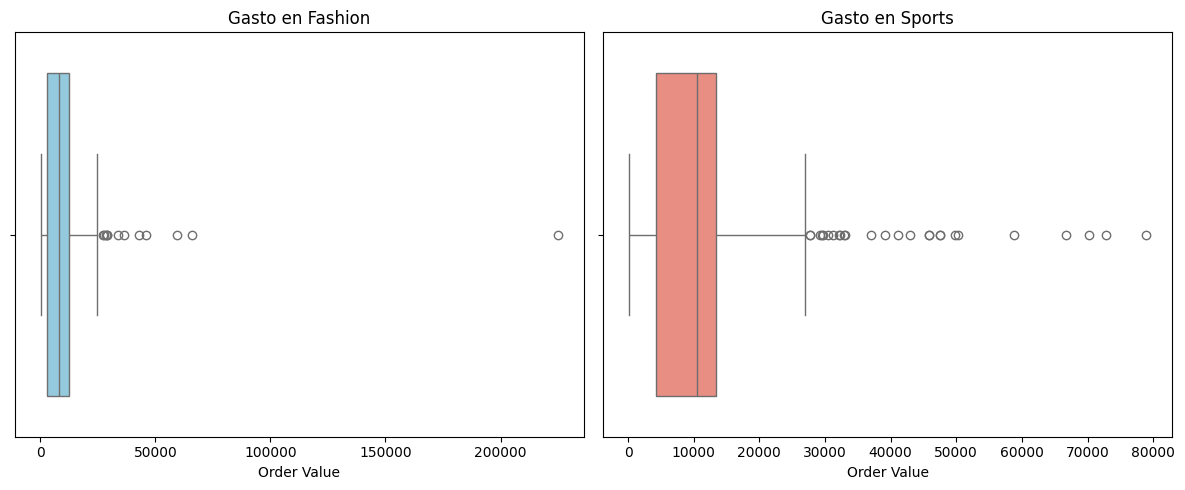

In [6]:
# Boxplots comparativos de gasto por categoría
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df_clean[df_clean['product_category'] == 'Fashion']['order_value'], color='skyblue')
plt.title("Gasto en Fashion")
plt.xlabel("Order Value")

plt.subplot(1, 2, 2)
sns.boxplot(x=df_clean[df_clean['product_category'] == 'Sports']['order_value'], color='salmon')
plt.title("Gasto en Sports")
plt.xlabel("Order Value")

plt.tight_layout()
plt.show()

In [7]:
# Detección estadística formal en 'price'
# 1. Método IQR
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_clean[(df_clean['price'] < lower_bound) | (df_clean['price'] > upper_bound)]

# 2. Método Z-Score (|z| > 3)
mean_p = df_clean['price'].mean()
std_p = df_clean['price'].std()
df_clean['z_score_price'] = (df_clean['price'] - mean_p) / std_p
outliers_z = df_clean[df_clean['z_score_price'].abs() > 3]

print(f"Límite inferior IQR: {lower_bound:.2f} | Límite superior IQR: {upper_bound:.2f}")
print(f"Total Outliers detectados por IQR: {len(outliers_iqr)}")
print(f"Total Outliers detectados por Z-Score: {len(outliers_z)}")

Límite inferior IQR: -721.38 | Límite superior IQR: 1785.62
Total Outliers detectados por IQR: 450
Total Outliers detectados por Z-Score: 78


## 5. Segmentación de Clientes y Negocio
Clasificación de órdenes por volumen de compra, grupo de edad y métodos de pago para estrategias comerciales.

In [8]:
# Función de segmentación por volumen y edad
def classify_volume(row):
    age = row["customer_age"]
    qty = row["quantity"]
    if pd.isna(age) or pd.isna(qty):
        return "Error en Datos"
    if qty > 22:
        return "Sr. High Volume" if age > 55 else "Jr. High Volume"
    else:
        return "Sr. Low Volume" if age > 55 else "Jr. Low Volume"

# Función de segmentación por volumen y método de pago
def classify_payment(row):
    card = row["payment_method"]
    qty = row["quantity"]
    if pd.isna(card) or pd.isna(qty):
        return "Error en Datos"
    is_card = card in ["credit_card", "debit_card"]
    if qty > 22:
        return "card_high_volume" if is_card else "no_card_high_volume"
    else:
        return "card_low_volume" if is_card else "no_card_low_volume"

# Aplicación de segmentaciones
df_clean["volume_segment"] = df_clean.apply(classify_volume, axis=1)
df_clean["payment_segment"] = df_clean.apply(classify_payment, axis=1)

print("--- Distribución Segmento Volumen & Edad ---")
print(df_clean["volume_segment"].value_counts())

print("\n--- Distribución Segmento Pago & Volumen ---")
print(df_clean["payment_segment"].value_counts())

--- Distribución Segmento Volumen & Edad ---
volume_segment
Jr. Low Volume     3030
Sr. High Volume    1199
Sr. Low Volume      736
Jr. High Volume      43
Name: count, dtype: int64

--- Distribución Segmento Pago & Volumen ---
payment_segment
card_low_volume        2725
no_card_low_volume     1041
card_high_volume        909
no_card_high_volume     333
Name: count, dtype: int64
